
#**Анализ факторов, влияющих на смысловую изменчивость законопроектов**

Этот файл содержит полный процесс анализа данных о законопроектах, включающий предобработку данных, построение регрессионной модели ??? и визуализацию результатов.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import pandas as pd
import re
from scipy.stats import pearsonr, spearmanr
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

###**Предобработка данных**

Откроем файл с данными, которые получились после парсинга, NLP-анализа текста и построяния косинусной близости:

In [6]:
data = pd.read_excel('final_result_enriched.xlsx')
data.head(2)

,bill_url,Инициатор,Профильный комитет,Дата внесения в ГД,Тематический блок / Отрасль законодательства,Статус,bill_id,input_doc_url,output_doc_url,text_a,text_b,score
0,https://sozd.duma.gov.ru/bill/1060950-7,"Депутаты Государственной Думы В.И.Пискарев, А....",Комитет Государственной Думы по государственно...,23.11.2020,Государственное строительство и конституционны...,принят,1060950-7,https://sozd.duma.gov.ru/download/4060a9be-554...,https://sozd.duma.gov.ru/download/ef4d51bf-0eb...,Вносится депутатами Государственной Думы В.И.П...,Проект № 1060950-7 в третьем чтении ФЕДЕРАЛЬНЫ...,0.526161
1,https://sozd.duma.gov.ru/bill/989758-7,"Депутаты Государственной Думы А.Е.Хинштейн, С....",Комитет Государственной Думы по государственно...,16.07.2020,Государственное строительство и конституционны...,принят,989758-7,https://sozd.duma.gov.ru/download/e25cc0fd-720...,https://sozd.duma.gov.ru/download/4d0cb173-0cc...,Вносится депутатами Государственной Думы А.Е. ...,Проект № 989758-7 в третьем чтении ФЕДЕРАЛЬНЫЙ...,0.522279


In [7]:
data.columns

Index(['bill_url', 'Инициатор', 'Профильный комитет', 'Дата внесения в ГД',
       'Тематический блок / Отрасль законодательства', 'Статус', 'bill_id',
       'input_doc_url', 'output_doc_url', 'text_a', 'text_b', 'score'],
      dtype='object')

In [8]:
data.shape

(5069, 12)


Полученные данные содержат столбцы, которые не будут использоваться в модели. Удалим их, оставив только те переменные, которые необходимы для дальнейшего анализа:

In [9]:
columns_to_drop = [
    'bill_url',
    'Тематический блок / Отрасль законодательства',
    'Статус',
    'bill_id',
    'input_doc_url',
    'output_doc_url',
    'text_b'
]

data = data.drop(columns=columns_to_drop)

In [10]:
data.head(2)

,Инициатор,Профильный комитет,Дата внесения в ГД,text_a,score
0,"Депутаты Государственной Думы В.И.Пискарев, А....",Комитет Государственной Думы по государственно...,23.11.2020,Вносится депутатами Государственной Думы В.И.П...,0.526161
1,"Депутаты Государственной Думы А.Е.Хинштейн, С....",Комитет Государственной Думы по государственно...,16.07.2020,Вносится депутатами Государственной Думы А.Е. ...,0.522279



Стандартизируем инициаторов: объединяем схожие формулировки (например, "депутаты Госдумы" и "депутат Госдумы") и кодируем их в числовой формат для дальнейшего анализа.

In [11]:
actor_normalization = {
    'депутаты государственной думы': 'state_duma',
    'депутат государственной думы': 'state_duma',
    'члены совета федерации': 'federation_council',
    'член совета федерации': 'federation_council',
    'сенаторы российской федерации': 'federation_council',
    'сенатор российской федерации': 'federation_council',
    'правительство российской федерации': 'government',
    'президент российской федерации': 'president',
    'суд российской федерации': 'court',

    'региональный парламент': 'regional_parliament',
    'законодательное собрание': 'regional_parliament',
    'областная дума': 'regional_parliament',
    'губернская дума': 'regional_parliament',
    'государственное собрание': 'regional_parliament',
    'народное собрание': 'regional_parliament',
    'государственный совет': 'regional_parliament',
    'верховный хурал': 'regional_parliament',
    'курултай': 'regional_parliament',
    'ил тумэн': 'regional_parliament',
    'городская дума': 'regional_parliament',
    'московская городская дума': 'regional_parliament',
    'парламент кабардино балкарской республики': 'regional_parliament',
}

label_map = {
    'state_duma': 'State_duma',
    'federation_council': 'Federation_council',
    'government': 'Government',
    'president': 'President',
    'court': 'Court',
    'regional_parliament': 'Regional_parliament',
}

order = [
    'state_duma',
    'federation_council',
    'government',
    'president',
    'court',
    'regional_parliament',
]

patterns = [
    # STATE DUMA
    (re.compile(r'\bдепутат(ы)?\s+государственной\s+дум(ы|а)\b', re.I), 'state_duma'),
    (re.compile(r'\bдепутаты\s+государственной\s+думы\b', re.I), 'state_duma'),

    # FEDERATION COUNCIL
    (re.compile(r'\bчлен(ы)?\s+совета\s+федераци[ияи]\b', re.I), 'federation_council'),
    (re.compile(r'\bчлены\s+совета\s+федерации\b', re.I), 'federation_council'),
    (re.compile(r'\bсенатор(ы)?\s+российской\s+федераци[ияи]\b', re.I), 'federation_council'),
    (re.compile(r'\bсовет\s+федераци[ияи]\b', re.I), 'federation_council'),

    # GOVERNMENT / PRESIDENT
    (re.compile(r'\bправительство\s+российской\s+федераци[ияи]\b', re.I), 'government'),
    (re.compile(r'\bпрезидент\s+российской\s+федераци[ияи]\b', re.I), 'president'),

    # COURT
    (re.compile(r'\b(конституционный|верховный|высший\s+арбитражный|арбитражный)\s+суд\b', re.I), 'court'),

    # REGIONAL PARLIAMENTS — базовые формы
    (re.compile(r'\bзаконодательн\w*\s+собрани\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bобластн\w*\s+собрани\w*\s+депутат\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bсобрани\w*\s+депутат\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bсовет\s+народн\w*\s+депутат\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bверховн\w*\s+совет\b', re.I), 'regional_parliament'),
    (re.compile(r'\b(народн\w*\s+)?хурал\b', re.I), 'regional_parliament'),
    (re.compile(r'\bгосударственн\w*\s+совет\b', re.I), 'regional_parliament'),
    (re.compile(r'\bгосударственн\w*\s+собрани\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bнародн\w*\s+собрани\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bкурултай\b', re.I), 'regional_parliament'),
    (re.compile(r'\bил[\s\-]?тумэн\b', re.I), 'regional_parliament'),

    # REGIONAL PARLIAMENTS — думы
    (re.compile(r'\bобластн\w*\s+дум\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bгубернск\w*\s+дум\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bгородск\w*\s+дум\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bмосковск\w*\s+городск\w*\s+дум\w*\b', re.I), 'regional_parliament'),

    # REGIONAL PARLIAMENTS — конструкции вида "Дума X области/края/округа/республики"
    (re.compile(r'\bдум\w*\s+[а-яё\-\s]+област\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bдум\w*\s+[а-яё\-\s]+кра[яй]\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bдум\w*\s+[а-яё\-\s]+округ\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bдум\w*\s+[а-яё\-\s]+республик\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bдум\w*\s+ханты[\-\s]мансийск\w*\s+автономн\w*\s+округ\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bдум\w*\s+чукотск\w*\s+автономн\w*\s+округ\w*\b', re.I), 'regional_parliament'),

    # REGIONAL PARLIAMENTS — парламенты субъектов
    (re.compile(r'\bпарламент\s+республик\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bпарламент\s+[а-яё\-\s]+республик\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bпарламент\s+[а-яё\-\s]+кра[яй]\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bпарламент\s+[а-яё\-\s]+област\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bпарламент\s+[а-яё\-\s]+округ\w*\b', re.I), 'regional_parliament'),

    # REGIONAL PARLIAMENTS — обобщённые старые паттерны
    (re.compile(
        r'\bдум\w*\s+'
        r'(?:республик\w+|кра[яй]\w*|област\w+|округ\w+|автономн\w+|города|г\.)\b',
        re.I
    ), 'regional_parliament'),

    (re.compile(
        r'\bпарламент\s+'
        r'(?:республик\w+|кра[яй]\w*|област\w+|округ\w+|автономн\w+)\b',
        re.I
    ), 'regional_parliament'),
]


def preprocess_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''

    t = text.lower().strip()

    t = t.replace('ё', 'е')
    t = t.replace('–', '-')
    t = t.replace('—', '-')
    t = t.replace(' - ', ' ')
    t = t.replace('-', ' ')

    t = re.sub(r'[^\w\s]', ' ', t, flags=re.U)
    t = re.sub(r'\s+', ' ', t).strip()

    return t


def extract_initiators(text: str):
    t = preprocess_text(text)

    if not t:
        return []

    found = set()

    for rx, code in patterns:
        if rx.search(t):
            found.add(code)

    for key, code in actor_normalization.items():
        key_norm = preprocess_text(key)
        if key_norm and key_norm in t:
            found.add(code)

    return [c for c in order if c in found]


def normalize_initiator_type(text: str):
    found = extract_initiators(text)
    if not found:
        return None
    return ', '.join(label_map[c] for c in found)


def make_initiator_category(text: str):
    found = extract_initiators(text)

    if not found:
        return 'Unknown'

    found_set = set(found)

    # один инициатор
    if len(found_set) == 1:
        only = found[0]
        return f'{label_map[only]}_only'

    # совместные исполнительные
    if found_set == {'government', 'president'}:
        return 'Executive_joint'

    # любые комбинации только парламентских акторов
    if found_set.issubset({'state_duma', 'federation_council', 'regional_parliament'}):
        return 'Parliamentary_joint'

    # смешанные парламентско-исполнительные комбинации
    if (
        any(x in found_set for x in ['state_duma', 'federation_council', 'regional_parliament']) and
        any(x in found_set for x in ['government', 'president'])
    ):
        return 'Mixed_parliamentary_executive_joint'

    # комбинации с судом
    if 'court' in found_set and len(found_set) > 1:
        return 'Court_joint'

    return 'Other_joint'


data['Initiator_type'] = data['Инициатор'].apply(normalize_initiator_type)
data['Initiator_category'] = data['Инициатор'].apply(make_initiator_category)

Стандартизируем профильные комитеты: объединяем различные формулировки и исторические наименования комитетов, а также случаи совместного рассмотрения законопроекта несколькими комитетами, в укрупнённые тематические блоки (например, «бюджет и налоги» и «финансовый рынок», в группу финансовой политики). Это позволяет сократить избыточную категориальную вариативность и сформировать содержательно осмысленные агрегированные группы для последующего количественного анализа.

In [12]:
committee_col = 'Профильный комитет'

def normalize_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text


def classify_committee(text):

    t = normalize_text(text)

    if not t:
        return 'OTHER'

    # SECURITY
    if any(k in t for k in [
        'обороне',
        'безопасности',
        'противодействию коррупции'
    ]):
        return 'SECURITY'

    # FOREIGN
    if any(k in t for k in [
        'международ',
        'содружеств',
        'евразий'
    ]):
        return 'FOREIGN'

    # FINANCE
    if any(k in t for k in [
        'бюджет',
        'налог',
        'финансов'
    ]):
        return 'FINANCE'

    # ENERGY
    if 'энергетик' in t:
        return 'ENERGY'

    # AGRO
    if 'аграр' in t:
        return 'AGRO'

    # ECOLOGY
    if any(k in t for k in [
        'природн',
        'эколог'
    ]):
        return 'ECOLOGY'

    # DIGITAL
    if any(k in t for k in [
        'информационной политике',
        'информационным технологиям',
        'связи'
    ]):
        return 'DIGITAL_INFO'

    # HEALTH
    if 'охране здоровья' in t:
        return 'HEALTH'

    # SOCIAL
    if any(k in t for k in [
        'труду',
        'социальной политике',
        'ветеран',
        'семьи, женщин'
    ]):
        return 'SOCIAL'

    # EDUCATION
    if any(k in t for k in [
        'образован',
        'наук',
        'культур'
    ]):
        return 'EDUCATION'

    # INFRA
    if any(k in t for k in [
        'транспорт',
        'строительств',
        'жилищ',
        'жкх',
        'земельн'
    ]):
        return 'INFRA'

    # ECONOMY
    if any(k in t for k in [
        'экономической политике',
        'промышленности',
        'предпринимательств',
        'инновационному',
        'собственност'
    ]):
        return 'ECONOMY'

    # LAW & STATE
    if any(k in t for k in [
        'государственному строительству',
        'конституционному законодательству',
        'гражданскому, уголовному',
        'процессуальному законодательству',
        'федеративному устройству',
        'регламент',
        'контрол',
        'гражданского общества',
        'национальност',
        'общественных объединений',
        'религиозных организаций'
    ]):
        return 'LAW_STATE'

    # REGIONAL
    if any(k in t for k in [
        'региональной политике',
        'севера и дальнего востока'
    ]):
        return 'REGIONAL'

    return 'OTHER'


data['committee_group'] = data[committee_col].apply(classify_committee)

Добавим переменную длины текста

In [13]:
data["score"] = pd.to_numeric(data["score"], errors="coerce")
data = data.dropna(subset=["score", "text_a"])

data["text_length_words"] = (
    data["text_a"]
    .astype(str)
    .str.split()
    .apply(len)
)

In [14]:
data = data[data["text_length_words"] > 0]

data["log_text_length_words"] = np.log(data["text_length_words"])

Добавим переменную года внесения законопроекта

In [15]:
data["Дата внесения в ГД"] = pd.to_datetime(
    data["Дата внесения в ГД"],
    format="%d.%m.%Y",
    errors="coerce"
)

data = data.dropna(subset=["Дата внесения в ГД", "score"])

data["depth"] = 1 - pd.to_numeric(data["score"], errors="coerce")

data["year"] = data["Дата внесения в ГД"].dt.year

In [16]:
data.head(2)

,Инициатор,Профильный комитет,Дата внесения в ГД,text_a,score,Initiator_type,Initiator_category,committee_group,text_length_words,log_text_length_words,depth,year
0,"Депутаты Государственной Думы В.И.Пискарев, А....",Комитет Государственной Думы по государственно...,2020-11-23,Вносится депутатами Государственной Думы В.И.П...,0.526161,"State_duma, Federation_council",Parliamentary_joint,INFRA,1324,7.188413,0.473839,2020
1,"Депутаты Государственной Думы А.Е.Хинштейн, С....",Комитет Государственной Думы по государственно...,2020-07-16,Вносится депутатами Государственной Думы А.Е. ...,0.522279,State_duma,State_duma_only,INFRA,882,6.782192,0.477721,2020


###**EDA**

Посмотрим на базовое распределение статистки:

In [17]:
score_col = "score"

score = pd.to_numeric(data[score_col], errors="coerce").dropna()
depth = 1 - score

def stats_row(x: pd.Series) -> dict:
    x = x.astype(float)
    return {
        "N": int(x.shape[0]),
        "Mean": float(x.mean()),
        "Std": float(x.std(ddof=1)),
        "Min": float(x.min()),
        "P01": float(x.quantile(0.01)),
        "P05": float(x.quantile(0.05)),
        "P10": float(x.quantile(0.10)),
        "Median": float(x.median()),
        "P90": float(x.quantile(0.90)),
        "P95": float(x.quantile(0.95)),
        "P99": float(x.quantile(0.99)),
        "Max": float(x.max()),
        "Skew": float(skew(x)),
        "Kurtosis(excess)": float(kurtosis(x, fisher=True)),
        "Share==0": float((x == 0).mean()),
        "Share==1": float((x == 1).mean()),
        "Any<0": bool((x < 0).any()),
    }

stats_df = pd.DataFrame(
    [stats_row(score), stats_row(depth)],
    index=["score", "cosine similarity"]
).round(4)

display(stats_df)

,N,Mean,Std,Min,P01,P05,P10,Median,P90,P95,P99,Max,Skew,Kurtosis(excess),Share==0,Share==1,Any<0
score,4845,0.0639,0.064,0.0000,0.0025,0.0070,0.0108,0.0433,0.1456,0.1908,0.3089,0.5262,2.305,7.4986,0.0017,0.0000,False
cosine similarity,4845,0.9361,0.064,0.4738,0.6911,0.8092,0.8544,0.9567,0.9892,0.9930,0.9975,1.0000,-2.305,7.4986,0.0000,0.0017,False


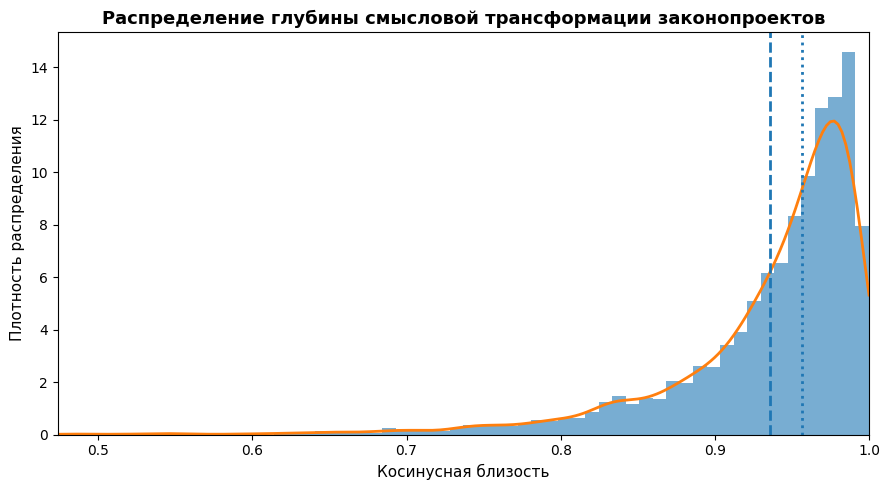

<Figure size 640x480 with 0 Axes>

In [23]:
depth = 1 - score

plt.figure(figsize=(9,5))

plt.hist(depth, bins=60, density=True, alpha=0.6)

xs = np.linspace(0, 1, 400)
kde = gaussian_kde(depth)
plt.plot(xs, kde(xs), linewidth=2)

plt.axvline(depth.mean(), linestyle="--", linewidth=2)
plt.axvline(depth.median(), linestyle=":", linewidth=2)

plt.xlim(depth.min(), depth.max())
plt.xlabel("Косинусная близость", fontsize=11)
plt.ylabel("Плотность распределения", fontsize=11)
plt.title("Распределение глубины смысловой трансформации законопроектов", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

Проанализируем распределение законопроектов по типам инициаторов и оценим их численность, а также сопоставим средние и распределительные характеристики показателя score в разрезе каждой группы, чтобы выявить возможные систематические различия в степени переработки законопроектов в зависимости от институционального источника инициативы.

In [24]:
score_col = 'score'
type_col = 'Initiator_type'
date_col = 'Дата внесения'

df = data.copy()

df[score_col] = pd.to_numeric(df[score_col], errors='coerce')

if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df['year'] = df[date_col].dt.year


print("\n=== Initiator_type: top combinations ===")
print(df[type_col].value_counts(dropna=False).head(30))

min_n = 50
df['proximity'] = 1 - df[score_col]

prox_col = 'proximity'

grp = (
    df.dropna(subset=[prox_col, type_col])
      .groupby(type_col)[prox_col]
      .agg(n='count', mean='mean', median='median', std='std',
           p10=lambda s: s.quantile(0.10),
           p90=lambda s: s.quantile(0.90))
      .sort_values('n', ascending=False)
)


=== Initiator_type: top combinations ===
Initiator_type
Government                                             2640
State_duma                                              994
State_duma, Federation_council                          428
President                                               330
Regional_parliament                                     279
Federation_council                                       90
Court                                                    63
State_duma, Regional_parliament                          14
State_duma, Federation_council, Regional_parliament       7
Name: count, dtype: int64


In [25]:
grp

,n,mean,median,std,p10,p90
Initiator_type,,,,,,
Government,2640,0.948419,0.967508,0.056907,0.880606,0.990516
State_duma,994,0.914357,0.931993,0.069853,0.831204,0.979862
"State_duma, Federation_council",428,0.914285,0.933718,0.073450,0.821844,0.981486
President,330,0.945565,0.962035,0.058976,0.859331,0.994698
Regional_parliament,279,0.925731,0.942948,0.064535,0.838552,0.987468
Federation_council,90,0.911595,0.929610,0.076152,0.843478,0.975723
Court,63,0.951062,0.959232,0.037290,0.889389,0.987857
"State_duma, Regional_parliament",14,0.906123,0.926413,0.053868,0.835707,0.961426
"State_duma, Federation_council, Regional_parliament",7,0.919589,0.927848,0.024687,0.891422,0.940773


In [28]:
print("\n=== Score by Initiator_type (combinations) ===")
print(grp.head(30))

big_groups = grp[grp['n'] >= min_n].index.tolist()

plot_df = df[df[type_col].isin(big_groups)].dropna(subset=[score_col, type_col])

top_k = 12
top_groups = grp.loc[big_groups].sort_values('n', ascending=False).head(top_k).index.tolist()

data_for_box = [plot_df.loc[plot_df[type_col] == g, prox_col].values for g in top_groups]


=== Score by Initiator_type (combinations) ===
                                                       n      mean    median  \
Initiator_type                                                                 
Government                                          2640  0.948419  0.967508   
State_duma                                           994  0.914357  0.931993   
State_duma, Federation_council                       428  0.914285  0.933718   
President                                            330  0.945565  0.962035   
Regional_parliament                                  279  0.925731  0.942948   
Federation_council                                    90  0.911595  0.929610   
Court                                                 63  0.951062  0.959232   
State_duma, Regional_parliament                       14  0.906123  0.926413   
State_duma, Federation_council, Regional_parlia...     7  0.919589  0.927848   

                                                         std       p10 

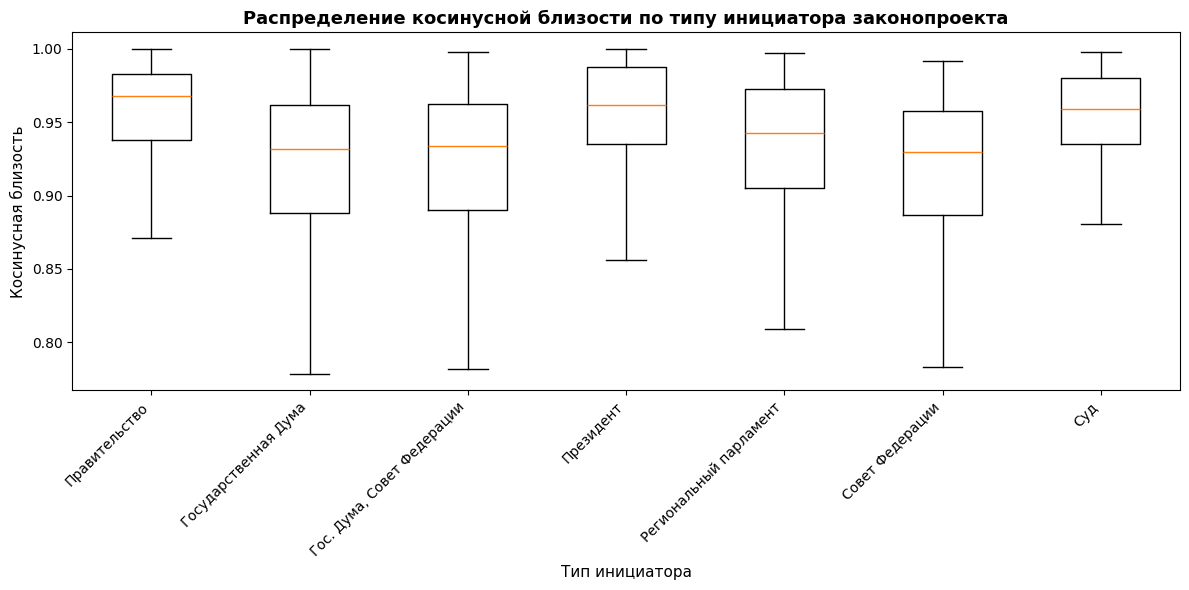

In [29]:
label_map = {
    "Government": "Правительство",
    "State_duma": "Государственная Дума",
    "State_duma, Federation_council": "Гос. Дума, Совет Федерации",
    "President": "Президент",
    "Regional_parliament": "Региональный парламент",
    "Federation_council": "Совет Федерации",
    "Court": "Суд",
    "State_duma, Regional_parliament": "Гос. Дума, Рег. парламент",
    "State_duma, Federation_council, Regional_parliament": "Гос. Дума, Совет Федерации, Рег. парламент",
}

top_groups_ru = [label_map.get(g, g) for g in top_groups]
plt.figure(figsize=(12, 6))
plt.boxplot(data_for_box, labels=top_groups_ru, vert=True, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title("Распределение косинусной близости по типу инициатора законопроекта", fontsize=13, fontweight="bold")
plt.ylabel("Косинусная близость", fontsize=11)
plt.xlabel("Тип инициатора", fontsize=11)
plt.tight_layout()
plt.show()

Проанализируем распределение законопроектов по профильным комитетам Государственной Думы и оценим численность каждой категории, чтобы выявить институциональную структуру парламентской специализации. Далее сопоставим основные описательные характеристики показателя score в разрезе комитетов, что позволит определить, связана ли степень переработки законопроектов с их тематической и процедурной юрисдикцией в рамках парламентской системы.

In [30]:
committee_col = 'committee_group'

df = data.copy()

df[committee_col] = df[committee_col].astype(str).str.strip()

n_committees = df[committee_col].nunique()

print("Количество уникальных комитетов:", n_committees)

Количество уникальных комитетов: 14


In [31]:
committee_counts = (
    df[committee_col]
      .value_counts()
      .reset_index()
      .rename(columns={'index': 'committee', committee_col: 'n_bills'})
)

print("\n=== Законопроекты по комитетам ===")
print(committee_counts.head(30))


=== Законопроекты по комитетам ===
         n_bills  count
0          INFRA   1263
1        FINANCE    982
2        FOREIGN    426
3      LAW_STATE    405
4       SECURITY    388
5        ECONOMY    331
6         SOCIAL    320
7        ECOLOGY    207
8      EDUCATION    177
9         HEALTH    112
10  DIGITAL_INFO     95
11        ENERGY     74
12          AGRO     57
13      REGIONAL      8


In [33]:
df['proximity'] = 1 - df['score']
prox_col = 'proximity'

committee_map = {
    "INFRA": "Инфраструктура",
    "FINANCE": "Финансы",
    "FOREIGN": "Международные дела",
    "LAW_STATE": "Гос. строительство и законодательство",
    "SECURITY": "Безопасность",
    "ECONOMY": "Экономика",
    "SOCIAL": "Социальная политика",
    "ECOLOGY": "Экология",
    "EDUCATION": "Образование",
    "HEALTH": "Здравоохранение",
    "DIGITAL_INFO": "Цифровые технологии и информация",
    "ENERGY": "Энергетика",
    "AGRO": "Аграрные вопросы",
    "REGIONAL": "Региональная политика",
}

min_n = 50

committee_stats = (
    df.dropna(subset=[prox_col, committee_col])
      .groupby(committee_col)[prox_col]
      .agg(n='count',
           mean='mean',
           median='median',
           std='std',
           p10=lambda s: s.quantile(0.10),
           p90=lambda s: s.quantile(0.90))
      .sort_values('n', ascending=False)
)

print("\n=== Proximity by committee ===")
print(committee_stats.head(20))


=== Proximity by committee ===
                    n      mean    median       std       p10       p90
committee_group                                                        
INFRA            1263  0.928611  0.955885  0.078043  0.830793  0.989265
FINANCE           982  0.939237  0.962981  0.065468  0.847343  0.992529
FOREIGN           426  0.931294  0.945584  0.048320  0.848314  0.976037
LAW_STATE         405  0.945598  0.960153  0.051117  0.882594  0.990980
SECURITY          388  0.949577  0.964621  0.047294  0.888766  0.991139
ECONOMY           331  0.933774  0.950620  0.063387  0.864486  0.986358
SOCIAL            320  0.941289  0.963305  0.055331  0.859473  0.988252
ECOLOGY           207  0.927370  0.950724  0.066532  0.846654  0.984773
EDUCATION         177  0.941180  0.960254  0.055071  0.869729  0.987587
HEALTH            112  0.938325  0.953564  0.055049  0.881149  0.986913
DIGITAL_INFO       95  0.926142  0.947297  0.062965  0.853942  0.980500
ENERGY             74  0.941721 

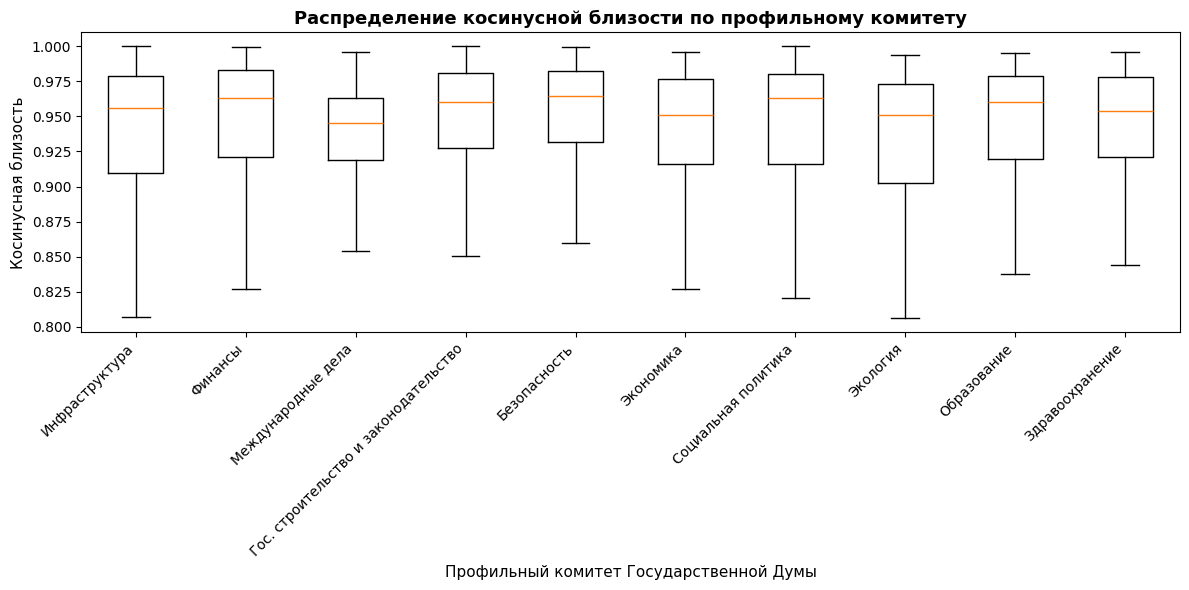

In [34]:
big_committees = committee_stats[committee_stats['n'] >= min_n].index.tolist()
top_k = 10
top_committees = committee_stats.loc[big_committees].head(top_k).index.tolist()

plot_df = df[df[committee_col].isin(top_committees)].dropna(subset=[prox_col])

data_for_box = [
    plot_df.loc[plot_df[committee_col] == c, prox_col].values
    for c in top_committees
]

top_committees_ru = [committee_map.get(c, c) for c in top_committees]

plt.figure(figsize=(12, 6))
plt.boxplot(data_for_box, tick_labels=top_committees_ru, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title("Распределение косинусной близости по профильному комитету", fontsize=13, fontweight="bold")
plt.ylabel("Косинусная близость", fontsize=11)
plt.xlabel("Профильный комитет Государственной Думы", fontsize=11)
plt.tight_layout()
plt.show()

Оценим связь между объёмом текста законопроекта и степенью его переработки. Для этого рассчитывается количество слов в исходной версии текста и определяется показатель глубины изменений (depth = 1 – cosine similarity). Далее будем вычислять коэффициенты корреляции Пирсона и Спирмена, позволяющие выявить линейную и монотонную зависимость между длиной текста и построим диаграмму рассеяния для визуального анализа распределения наблюдений.

Pearson correlation: PearsonRResult(statistic=np.float64(0.15171913453929564), pvalue=np.float64(2.4219052052771378e-26))
Spearman correlation: SignificanceResult(statistic=np.float64(0.3545201090278521), pvalue=np.float64(1.8137658509146402e-143))


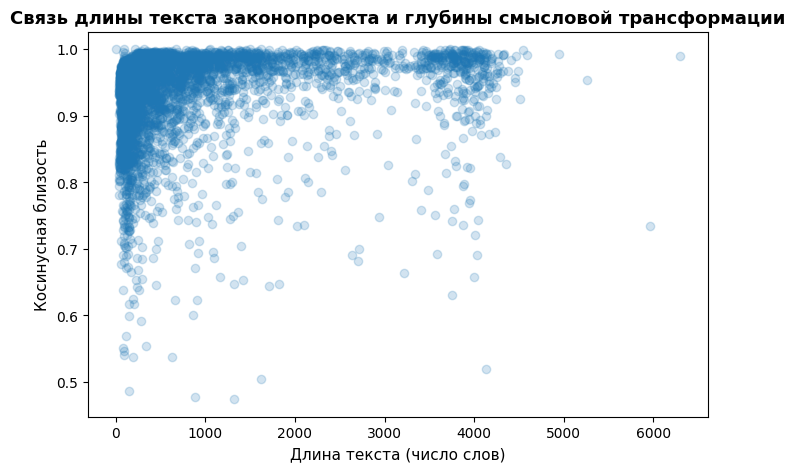

In [ ]:
data["depth"] = 1 - data["score"]

pearson_corr = pearsonr(data["text_length_words"], data["depth"])
spearman_corr = spearmanr(data["text_length_words"], data["depth"])

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)


plt.figure(figsize=(8,5))
plt.scatter(data["text_length_words"], data["depth"], alpha=0.2)
plt.xlabel("Длина текста (число слов)", fontsize=11)
plt.ylabel("Косинусная близость", fontsize=11)
plt.title("Связь длины текста законопроекта и глубины смысловой трансформации", fontsize=13, fontweight="bold")
plt.show()

Проверим, не образуют ли наиболее объемные законопроекты отдельную группу с особыми характеристиками переработки, способную повлиять на общую зависимость между длиной текста и глубиной изменений.

In [ ]:
data["text_length_words"].describe(percentiles=[.75, .9, .95, .99])

,text_length_words
count,4845.000000
mean,810.116615
std,1069.543662
min,1.000000
50%,329.000000
75%,947.000000
90%,2470.600000
95%,3719.800000
99%,4134.240000
max,6292.000000


In [ ]:
long_texts = data[data["text_length_words"] > 3500]

print("Количество длинных текстов:", len(long_texts))

Количество длинных текстов: 322


In [ ]:
long_texts["Initiator_type"].value_counts()

,count
Initiator_type,
Government,202
State_duma,50
"State_duma, Federation_council",37
President,26
Court,5
Federation_council,2


In [ ]:
long_texts["committee_group"].value_counts()

,count
committee_group,
FINANCE,105
INFRA,64
ECONOMY,36
ECOLOGY,26
SECURITY,22
SOCIAL,20
LAW_STATE,18
EDUCATION,14
FOREIGN,5


Посмотрим на динамику глубины переработки законопроектов во времени. Для этого сгруппируем наблюдения по годам внесения инициативы, рассчитаем среднее и медианное значение показателя глубины (1 – cosine similarity) для каждого года и визуализируем полученные значения. Это позволит оценить, присутствует ли временной тренд в степени изменений текста законопроектов.

In [ ]:
yearly = (
    data
    .groupby("year")["depth"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

print(yearly)

    year      mean    median  count
0   2011  0.964701  0.978068      4
1   2012  0.929030  0.951933    393
2   2013  0.934314  0.956146    459
3   2014  0.934414  0.956065    538
4   2015  0.931883  0.952539    450
5   2016  0.942983  0.960654    442
6   2017  0.933114  0.951568    536
7   2018  0.934792  0.954940    577
8   2019  0.939678  0.959416    522
9   2020  0.938642  0.963621    555
10  2021  0.942408  0.963962    369


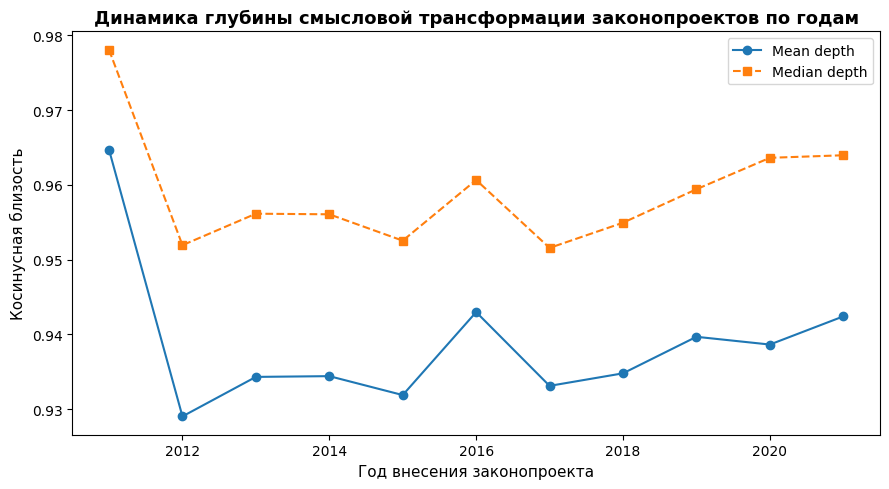

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(yearly["year"], yearly["mean"], marker="o", label="Mean depth")
plt.plot(yearly["year"], yearly["median"], marker="s", linestyle="--", label="Median depth")

plt.xlabel("Год внесения законопроекта", fontsize=11)
plt.ylabel("Косинусная близость", fontsize=11)
plt.title("Динамика глубины смысловой трансформации законопроектов по годам", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

Посмотрим на законопроекты с наибольшим количеством поправок

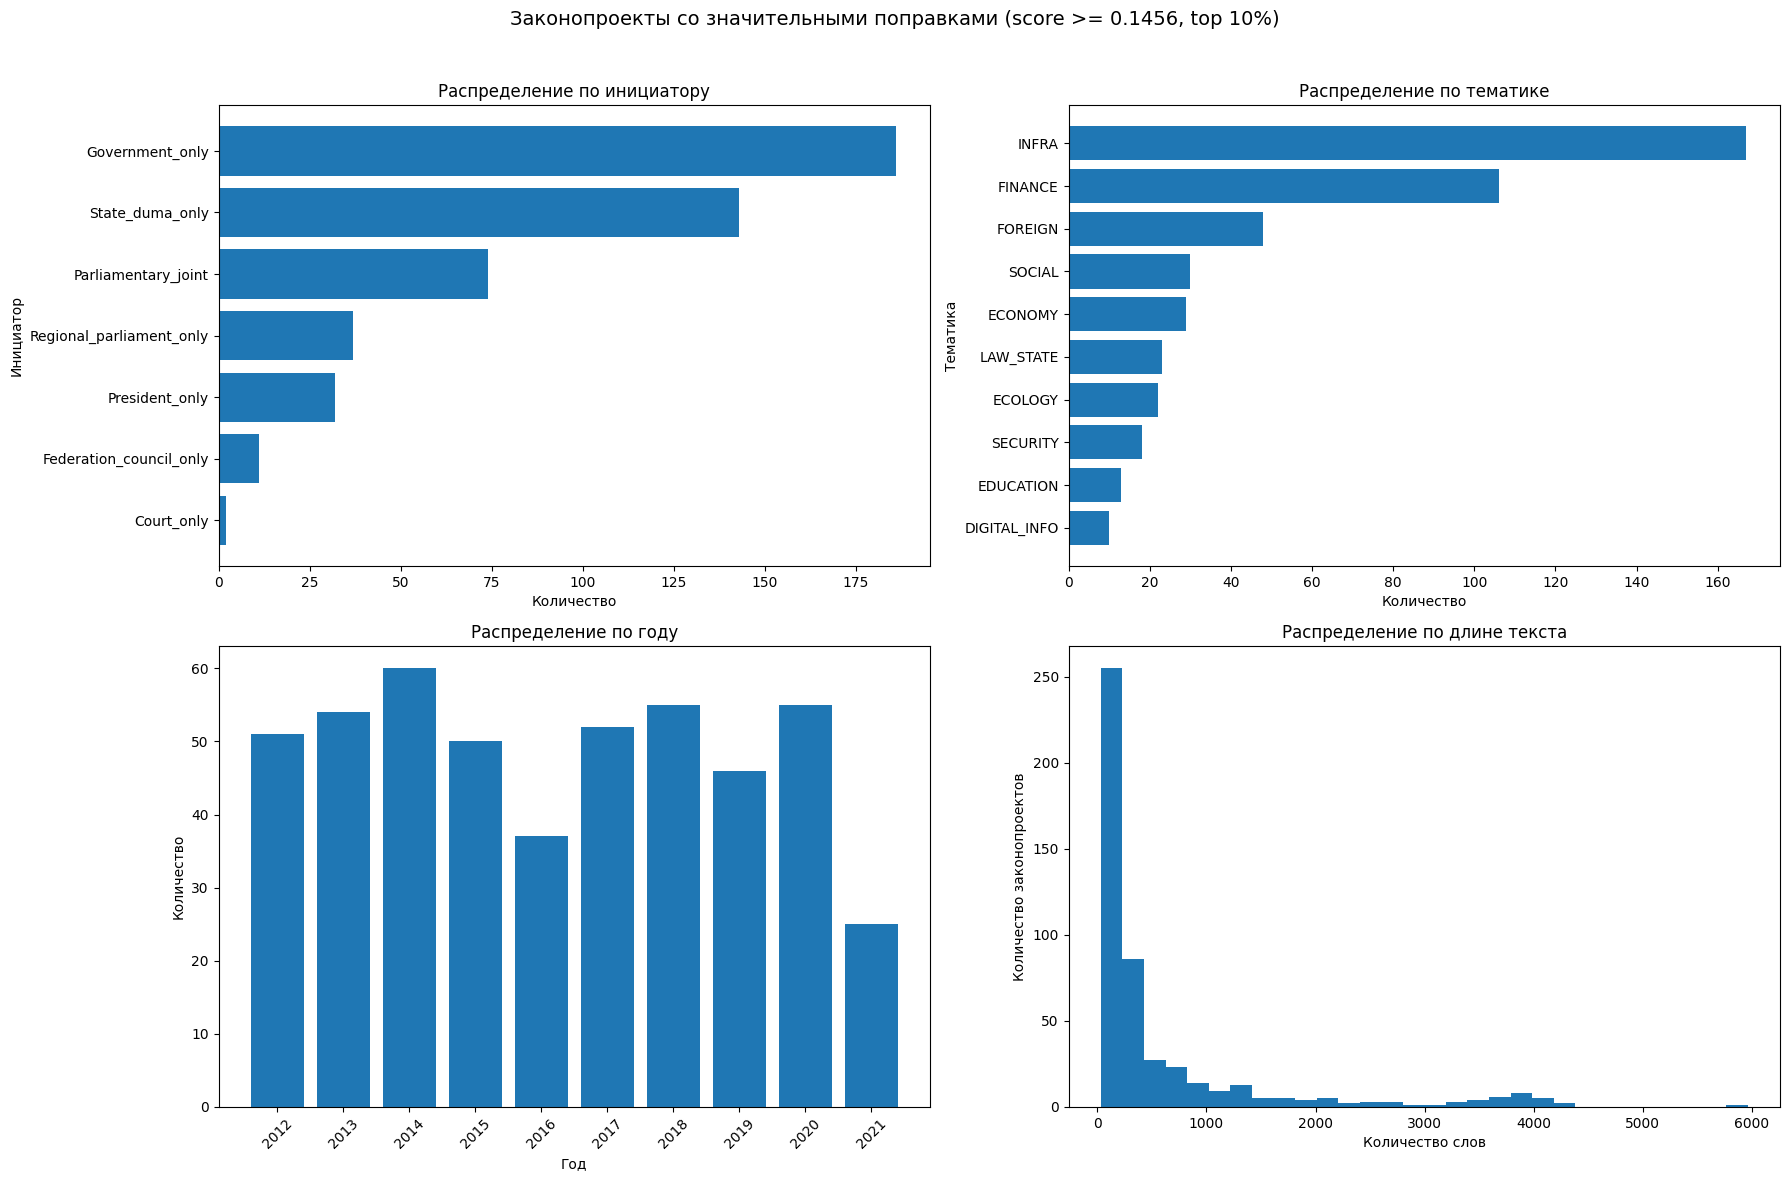

In [ ]:
score_col = 'score'
initiator_col = 'Initiator_category'
theme_col = 'committee_group'
year_col = 'year'
length_col = 'text_length_words'

quantile_level = 0.90
top_n_categories = 10

df = data.copy()
df[score_col] = pd.to_numeric(df[score_col], errors='coerce')
df[length_col] = pd.to_numeric(df[length_col], errors='coerce')
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')

df = df[df[score_col].notna()].copy()

threshold = df[score_col].quantile(quantile_level)
sig_df = df[df[score_col] >= threshold].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    f'Законопроекты со значительными поправками (score >= {threshold:.4f}, top 10%)',
    fontsize=14
)

# 1. Инициатор
initiator_counts = (
    sig_df[initiator_col]
    .fillna('Missing')
    .astype(str)
    .value_counts()
    .head(top_n_categories)
    .sort_values()
)

axes[0, 0].barh(initiator_counts.index, initiator_counts.values)
axes[0, 0].set_title('Распределение по инициатору')
axes[0, 0].set_xlabel('Количество')
axes[0, 0].set_ylabel('Инициатор')

# 2. Тематика
theme_counts = (
    sig_df[theme_col]
    .fillna('Missing')
    .astype(str)
    .value_counts()
    .head(top_n_categories)
    .sort_values()
)

axes[0, 1].barh(theme_counts.index, theme_counts.values)
axes[0, 1].set_title('Распределение по тематике')
axes[0, 1].set_xlabel('Количество')
axes[0, 1].set_ylabel('Тематика')

# 3. Год
year_counts = (
    sig_df[year_col]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

axes[1, 0].bar(year_counts.index.astype(str), year_counts.values)
axes[1, 0].set_title('Распределение по году')
axes[1, 0].set_xlabel('Год')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Длина текста
axes[1, 1].hist(sig_df[length_col].dropna(), bins=30)
axes[1, 1].set_title('Распределение по длине текста')
axes[1, 1].set_xlabel('Количество слов')
axes[1, 1].set_ylabel('Количество законопроектов')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

###**Построение моделей**

In [ ]:
df = data.copy()

df = df.dropna(subset=[
    "depth",
    "Initiator_category",
    "committee_group",
    "text_length_words",
    "year"
]).copy()

df = df[df["depth"].between(0, 1, inclusive="both")].copy()
df["year_c"] = df["year"] - df["year"].mean()

n = len(df)
df["depth_beta"] = (df["depth"] * (n - 1) + 0.5) / n
df["log_text_len"] = np.log1p(df["text_length_words"])

print(f"Наблюдений после очистки: {n}")
print(f"depth_beta: min={df['depth_beta'].min():.4f}, max={df['depth_beta'].max():.4f}")

CONTROLS = ["log_text_len", "year"]

try:
    from statsmodels.othermod.betareg import BetaModel
    BETA_AVAILABLE = True
    print("BetaModel доступен, используем beta-регрессию\n")
except ImportError:
    BETA_AVAILABLE = False
    print("BetaModel недоступен, используем GLM Binomial (логит-линк)\n")


def fit_model(formula, data, label=""):
    if BETA_AVAILABLE:
        result = BetaModel.from_formula(formula, data=data).fit(disp=False)
    else:
        result = smf.glm(
            formula=formula,
            data=data,
            family=sm.families.Binomial(link=sm.families.links.Logit())
        ).fit()
    print(f"\n{'='*60}\n  {label}\n{'='*60}")
    print(result.summary())
    return result


def get_coef_df(result):
    params = result.params
    bse = result.bse
    pvalues = result.pvalues
    conf = result.conf_int()
    return pd.DataFrame({
        "coef": params,
        "se": bse,
        "pvalue": pvalues,
        "ci_low": conf.iloc[:, 0],
        "ci_high": conf.iloc[:, 1],
    })

Наблюдений после очистки: 4845
depth_beta: min=0.4738, max=0.9999
BetaModel доступен, используем beta-регрессию



In [ ]:
m1 = fit_model(
    "depth_beta ~ C(Initiator_category) + log_text_len + year_c",
    df,
    "Модель 1 — категория инициатора"
)


  Модель 1 — категория инициатора
                              BetaModel Results                               
Dep. Variable:             depth_beta   Log-Likelihood:                 8984.6
Model:                      BetaModel   AIC:                        -1.795e+04
Method:            Maximum Likelihood   BIC:                        -1.788e+04
Date:                Sun, 03 May 2026                                         
Time:                        13:22:44                                         
No. Observations:                4845                                         
Df Residuals:                    4835                                         
Df Model:                           8                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept         

In [ ]:
m2 = fit_model(
    "depth_beta ~ C(committee_group) + log_text_len + year_c",
    df,
    "Модель 2 — тип законопроекта"
)


  Модель 2 — тип законопроекта
                              BetaModel Results                               
Dep. Variable:             depth_beta   Log-Likelihood:                 8779.6
Model:                      BetaModel   AIC:                        -1.753e+04
Method:            Maximum Likelihood   BIC:                        -1.741e+04
Date:                Sun, 03 May 2026                                         
Time:                        13:22:47                                         
No. Observations:                4845                                         
Df Residuals:                    4828                                         
Df Model:                          15                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              1.1316      

In [ ]:
m3 = fit_model(
    "depth_beta ~ C(Initiator_category) + C(committee_group) + log_text_len + year_c",
    df,
    "Модель 3 — инициатор и тип законопроекта"
)


  Модель 3 — инициатор и тип законопроекта
                              BetaModel Results                               
Dep. Variable:             depth_beta   Log-Likelihood:                 9024.9
Model:                      BetaModel   AIC:                        -1.800e+04
Method:            Maximum Likelihood   BIC:                        -1.785e+04
Date:                Sun, 03 May 2026                                         
Time:                        13:22:50                                         
No. Observations:                4845                                         
Df Residuals:                    4822                                         
Df Model:                          21                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept

###**Дополнительные модели**

Построим вариацию модели 2, будем определять отрасль через число ФОИВов

In [ ]:
foiv_counts = {
    "SECURITY":   16,
    "ECONOMY":    14,
    "FINANCE":     7,
    "ECOLOGY":     7,
    "INFRA":       7,
    "LAW_STATE":   4,
    "HEALTH":      4,
    "EDUCATION":   4,
    "SOCIAL":      4,
    "DIGITAL_INFO":4,
    "AGRO":        3,
    "FOREIGN":     2,
    "REGIONAL":    2,
    "ENERGY":      1,
    "OTHER":       np.nan,
}

df["n_foiv"] = df["committee_group"].map(foiv_counts)
df["n_foiv_std"] = (df["n_foiv"] - df["n_foiv"].mean()) / df["n_foiv"].std()

df_foiv = df.dropna(subset=["n_foiv"]).copy()

m2b = fit_model(
    "depth_beta ~ n_foiv_std + log_text_len + year_c",
    df_foiv,
    "Модель 2b — число ФОИВов"
)


  Модель 2b — число ФОИВов
                              BetaModel Results                               
Dep. Variable:             depth_beta   Log-Likelihood:                 8734.5
Model:                      BetaModel   AIC:                        -1.746e+04
Method:            Maximum Likelihood   BIC:                        -1.743e+04
Date:                Sun, 03 May 2026                                         
Time:                        13:22:58                                         
No. Observations:                4845                                         
Df Residuals:                    4840                                         
Df Model:                           3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.4762      0.056     26.542      0.000       1.367       1.585
n_foiv_std      -0

In [ ]:
print("\n" + "=" * 60)
print("  СРАВНЕНИЕ M2a vs M2b")
print("=" * 60)
for name, m in [("M2a (дамми сфер)", m2), ("M2b (число ФОИВов)", m2b)]:
    n_params = len(m.params)
    print(f"{name}:  AIC={m.aic:.2f}  BIC={m.bic:.2f}  LogLik={m.llf:.2f}  params={n_params}")

delta_aic = m2b.aic - m2.aic
print(f"\nΔAIC (M2b - M2a) = {delta_aic:.2f}")
if delta_aic > 0:
    print("M2a лучше по AIC (дамми сфер объясняют больше)")
else:
    print("M2b лучше по AIC (число ФОИВов достаточно)")


  СРАВНЕНИЕ M2a vs M2b
M2a (дамми сфер):  AIC=-17525.26  BIC=-17415.00  LogLik=8779.63  params=17
M2b (число ФОИВов):  AIC=-17459.04  BIC=-17426.62  LogLik=8734.52  params=5

ΔAIC (M2b - M2a) = 66.21
M2a лучше по AIC (дамми сфер объясняют больше)


Построим вариацию модели 2, будем определять отрасль через долю в федеральном бюджете

In [ ]:
df["budget_share"] = df["committee_group"].map(budget_share)
df["budget_share_std"] = (df["budget_share"] - df["budget_share"].mean()) / df["budget_share"].std()
df_budget = df.dropna(subset=["budget_share"]).copy()

budget_total = 16713.0


budget_by_sphere = {
    # Общегосударственные вопросы (1257 млрд) -> LAW_STATE
    # Логика: расходы на функционирование госаппарата, судебной системы,
    # законодательных органов
    "LAW_STATE": 1257.12,

    # Национальная оборона (2827) + Нац. безопасность (1972) -> SECURITY
    "SECURITY": 2827.01 + 1971.58,

    # Национальная экономика (2402) -> делится между ECONOMY, ENERGY, AGRO, INFRA
    # Подразделы нац. экономики (приблизительная структура 2016):
    # - ТЭК: ~27 млрд -> ENERGY
    # - Сельское хозяйство: ~258 млрд -> AGRO
    # - Транспорт + дорожное хоз-во: ~820 млрд -> INFRA (часть)
    # - Остальное (промышленность, связь, прочее): ~1297 млрд -> ECONOMY
    "ENERGY": 27.0,
    "AGRO": 258.0,
    "ECONOMY": 1297.0,

    # ЖКХ (149) -> INFRA (добавляем к транспорту)
    # Транспорт из нац. экономики (~820) + ЖКХ (149) = ~969
    "INFRA": 820.0 + 148.79,

    # Охрана окружающей среды (116) -> ECOLOGY
    "ECOLOGY": 115.98,

    # Образование (723) + Культура (95) -> EDUCATION
    "EDUCATION": 722.62 + 94.85,

    # Здравоохранение (537) -> HEALTH
    "HEALTH": 537.31,

    # Социальная политика (4582) + Физкультура и спорт (64) -> SOCIAL
    "SOCIAL": 4581.80 + 64.02,

    # СМИ (88) -> DIGITAL_INFO
    "DIGITAL_INFO": 88.45,

    # Международные дела: нет отдельного раздела, часть «Общегосударственных вопросов»
    # Подраздел «Международные отношения и международное сотрудничество» ~108 млрд
    "FOREIGN": 108.0,

    # Региональная политика: нет отдельного раздела
    # Межбюджетные трансферты (1095) как прокси
    "REGIONAL": 1095.42,
}

budget_share = {k: v / budget_total for k, v in budget_by_sphere.items()}

#df_budget = df.dropna(subset=["budget_share"]).copy()

m2c = fit_model(
    "depth_beta ~ budget_share_std + log_text_len + year_c",
    df_budget,
    "Модель 2c — доля в федеральном бюджете"
)


  Модель 2c — доля в федеральном бюджете
                              BetaModel Results                               
Dep. Variable:             depth_beta   Log-Likelihood:                 6959.2
Model:                      BetaModel   AIC:                        -1.391e+04
Method:            Maximum Likelihood   BIC:                        -1.388e+04
Date:                Sun, 03 May 2026                                         
Time:                        13:25:12                                         
No. Observations:                3863                                         
Df Residuals:                    3858                                         
Df Model:                           3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.5013      0.059     25.328      0.000       1.385     

In [ ]:
print("\n" + "=" * 60)
print("  СРАВНЕНИЕ M2a vs M2b vs M2c")
print("=" * 60)

print(f"\nΔAIC M2b - M2a = {m2b.aic - m2.aic:.2f}")
print(f"ΔAIC M2c - M2a = {m2c.aic - m2.aic:.2f}")


  СРАВНЕНИЕ M2a vs M2b vs M2c

ΔAIC M2b - M2a = 66.21
ΔAIC M2c - M2a = 3616.86


Построим вариацию модели 2, добавим два предиктора одновременно

In [ ]:
df_both = df.dropna(subset=["n_foiv", "budget_share"]).copy()

m2d = fit_model(
    "depth_beta ~ n_foiv_std + budget_share_std + log_text_len + year_c",
    df_both,
    "Модель 2d — ФОИВы + доля бюджета"
)


  Модель 2d — ФОИВы + доля бюджета
                              BetaModel Results                               
Dep. Variable:             depth_beta   Log-Likelihood:                 6966.6
Model:                      BetaModel   AIC:                        -1.392e+04
Method:            Maximum Likelihood   BIC:                        -1.388e+04
Date:                Sun, 03 May 2026                                         
Time:                        13:25:29                                         
No. Observations:                3863                                         
Df Residuals:                    3857                                         
Df Model:                           4                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.4525      0.061     23.928      0.000       1.334       1.57

In [ ]:
m3_interact = fit_model(
    "depth_beta ~ C(Initiator_category) * budget_share_std + log_text_len + year_c",
    df_both,
    "Модель 3 (interaction) — инициатор × доля бюджета"
)


  Модель 3 (interaction) — инициатор × доля бюджета
                              BetaModel Results                               
Dep. Variable:             depth_beta   Log-Likelihood:                 7169.4
Model:                      BetaModel   AIC:                        -1.430e+04
Method:            Maximum Likelihood   BIC:                        -1.420e+04
Date:                Sun, 03 May 2026                                         
Time:                        13:25:32                                         
No. Observations:                3863                                         
Df Residuals:                    3846                                         
Df Model:                          15                                         
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [ ]:
print("\n" + "=" * 60)
print("  СРАВНЕНИЕ РАСШИРЕННЫХ МОДЕЛЕЙ")
print("=" * 60)

for name, m in [
    ("M2a (дамми сфер)", m2),
    ("M2d (ФОИВы + бюджет)", m2d),
    ("M3 базовая", m3),
    ("M3 interaction", m3_interact),
]:
    print(f"{name:30s}  AIC={m.aic:.2f}  BIC={m.bic:.2f}  k={len(m.params)}")


  СРАВНЕНИЕ РАСШИРЕННЫХ МОДЕЛЕЙ
M2a (дамми сфер)                AIC=-17525.26  BIC=-17415.00  k=17
M2d (ФОИВы + бюджет)            AIC=-13921.16  BIC=-13883.61  k=6
M3 базовая                      AIC=-18003.78  BIC=-17854.61  k=23
M3 interaction                  AIC=-14304.83  BIC=-14198.43  k=17


Построим визуализацию

In [ ]:
def plot_coefs(result, title, vars_to_plot=None, xlabel="Оценка коэффициента"):
    tbl = get_coef_df(result).copy()
    tbl = tbl.apply(pd.to_numeric, errors="coerce")
    tbl = tbl[~tbl.index.isin(["Intercept", "precision"])].copy()

    if vars_to_plot is not None:
        tbl = tbl[tbl.index.isin(vars_to_plot)].copy()
    tbl = tbl.dropna(subset=["coef", "se"]).copy()

    if tbl.empty:
        print(f"Нет данных для визуализации: {title}")
        return

    def pretty_label(var_name):
        initiator_map = {
            "Federation_council_only": "Совет Федерации",
            "Government_only": "Правительство",
            "Parliamentary_joint": "Совместная парламентская инициатива",
            "President_only": "Президент",
            "Regional_parliament_only": "Региональные парламенты",
            "State_duma_only": "Государственная Дума",
        }
        committee_map = {
            "DIGITAL_INFO": "Цифровая политика и информация",
            "ECOLOGY": "Экология",
            "ECONOMY": "Экономика",
            "EDUCATION": "Образование и наука",
            "ENERGY": "Энергетика",
            "FINANCE": "Финансы",
            "FOREIGN": "Международные отношения",
            "HEALTH": "Здравоохранение",
            "INFRA": "Инфраструктура и ЖКХ",
            "LAW_STATE": "Государственное строительство и законодательство",
            "REGIONAL": "Региональная политика",
            "SECURITY": "Безопасность",
            "SOCIAL": "Социальная политика",
        }

        # Интеракции: Инициатор × Доля бюджета
        if ":budget_share_std" in var_name:
            base = var_name.split(":budget_share_std")[0]
            if base.startswith("C(Initiator_category)[T."):
                value = base.replace("C(Initiator_category)[T.", "").replace("]", "")
                initiator = initiator_map.get(value, value.replace("_", " "))
                return f"{initiator} × Доля бюджета"
            return f"{base.replace('_', ' ')} × Доля бюджета"

        # Интеракции: Инициатор × Число ФОИВов
        if ":n_foiv_std" in var_name:
            base = var_name.split(":n_foiv_std")[0]
            if base.startswith("C(Initiator_category)[T."):
                value = base.replace("C(Initiator_category)[T.", "").replace("]", "")
                initiator = initiator_map.get(value, value.replace("_", " "))
                return f"{initiator} × Число ФОИВов"
            return f"{base.replace('_', ' ')} × Число ФОИВов"

        # Основные эффекты категориальных переменных
        if var_name.startswith("C(Initiator_category)[T."):
            value = var_name.replace("C(Initiator_category)[T.", "").replace("]", "")
            return initiator_map.get(value, value.replace("_", " "))

        if var_name.startswith("C(committee_group)[T."):
            value = var_name.replace("C(committee_group)[T.", "").replace("]", "")
            return committee_map.get(value, value.replace("_", " "))

        # Стандартизированные предикторы
        if var_name == "n_foiv_std":
            return "Число ФОИВов"
        if var_name == "budget_share_std":
            return "Доля в федеральном бюджете"

        if var_name == "log_text_len":
            return "Длина текста"
        if var_name == "year":
            return "Год внесения"
        if var_name == "year_c":
            return "Год внесения"

        return var_name.replace("_", " ")

    tbl["label"] = [pretty_label(v) for v in tbl.index]
    tbl["significant"] = tbl["pvalue"] < 0.05
    tbl = tbl.sort_values("coef").copy()

    plt.figure(figsize=(10, max(5, len(tbl) * 0.55)))

    for i, (_, row) in enumerate(tbl.iterrows()):
        color = "firebrick" if row["significant"] else "gray"
        plt.errorbar(
            x=row["coef"],
            y=i,
            xerr=1.96 * row["se"],
            fmt="o",
            color=color,
            ecolor=color,
            capsize=4,
            markersize=6,
            linewidth=1.4,
        )

    plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
    plt.yticks(range(len(tbl)), tbl["label"], fontsize=10)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Переменная", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.grid(axis="x", linestyle=":", linewidth=0.7)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="firebrick",
               markersize=8, label="p < 0,05"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
               markersize=8, label="p ≥ 0,05"),
    ]
    plt.legend(handles=legend_elements, fontsize=10, loc="lower right")

    plt.tight_layout()
    plt.show()

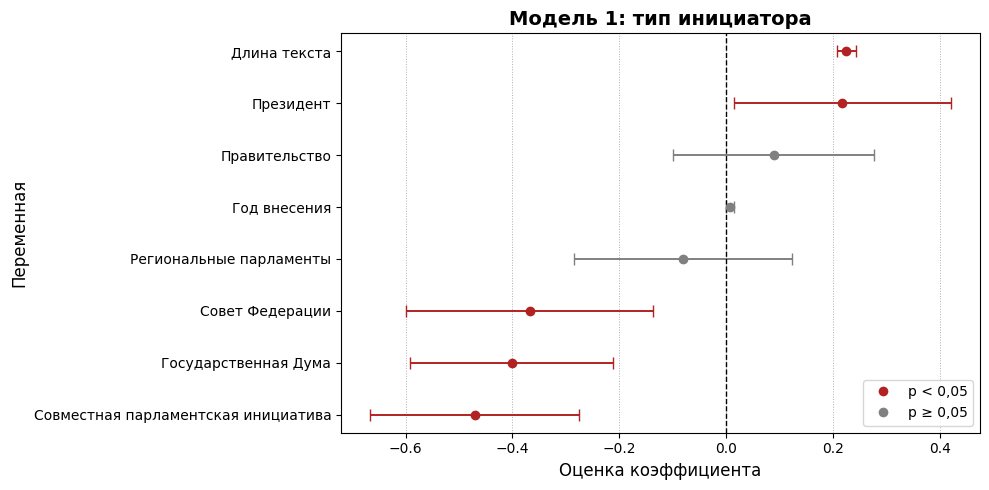

In [ ]:
plot_coefs(m1, "Модель 1: тип инициатора")

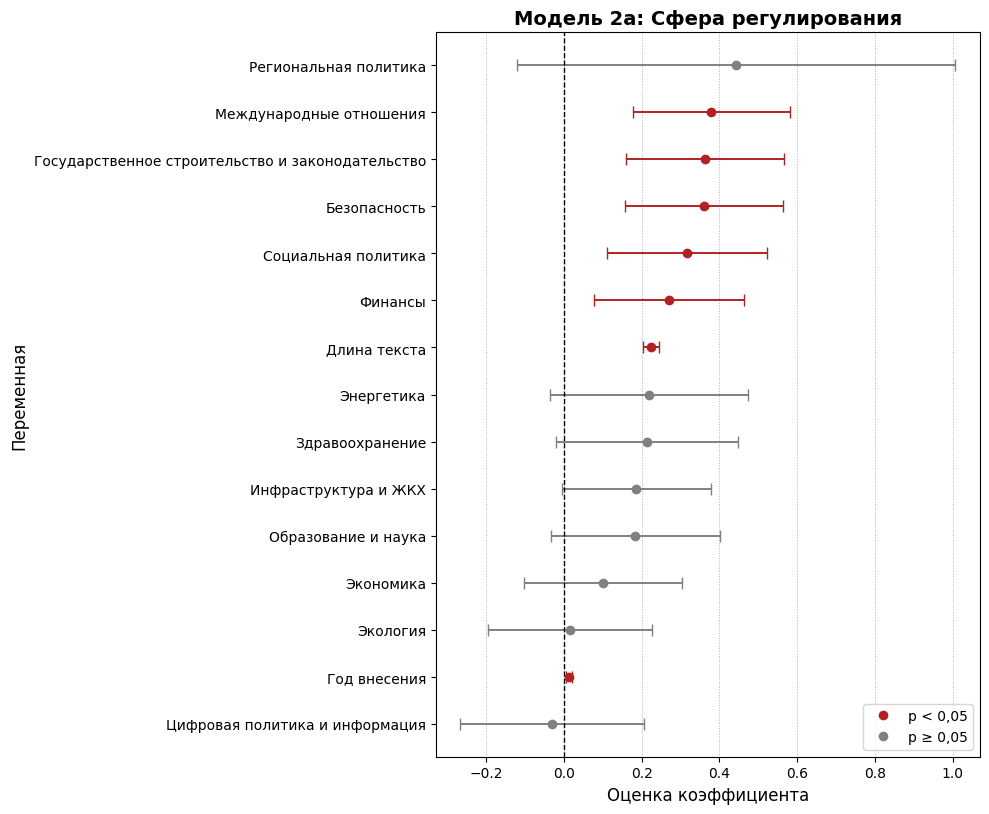

In [ ]:
plot_coefs(m2, "Модель 2a: Cфера регулирования")

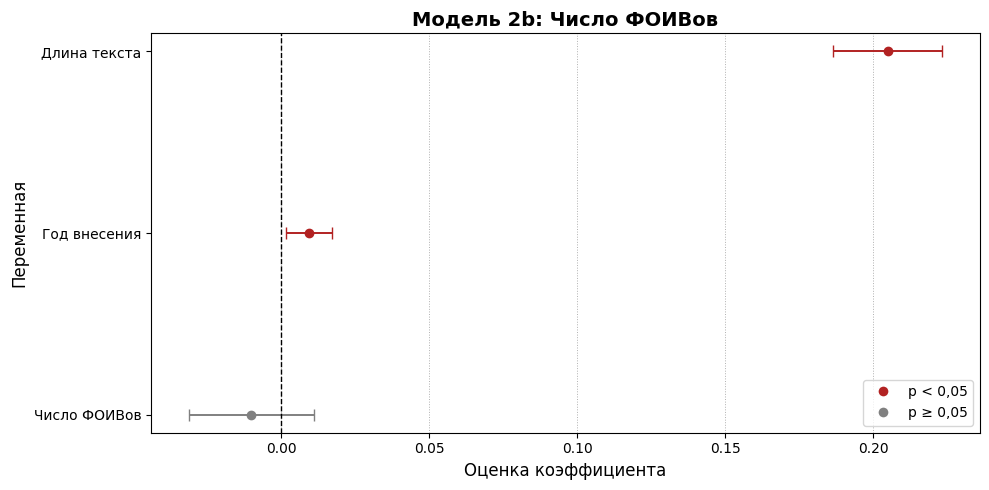

In [ ]:
plot_coefs(m2b, "Модель 2b: Число ФОИВов")

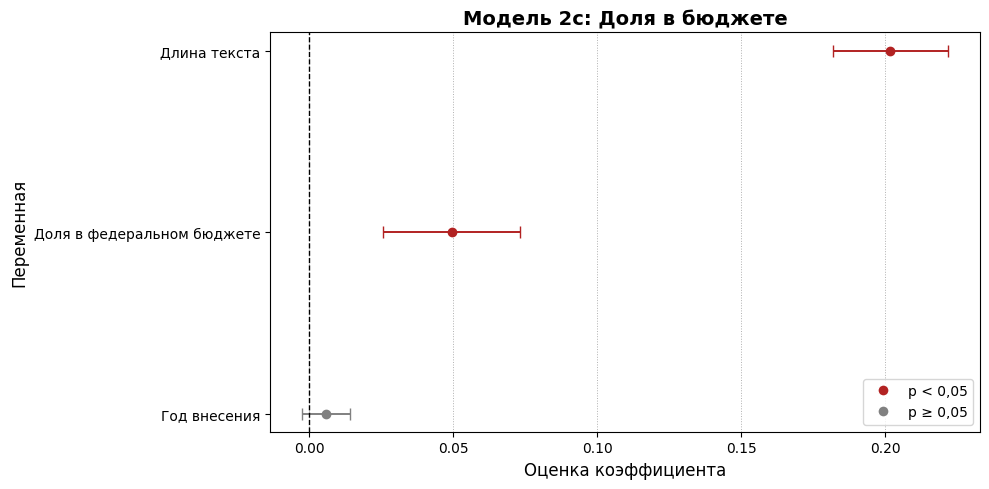

In [ ]:
plot_coefs(m2c, "Модель 2c: Доля в бюджете")

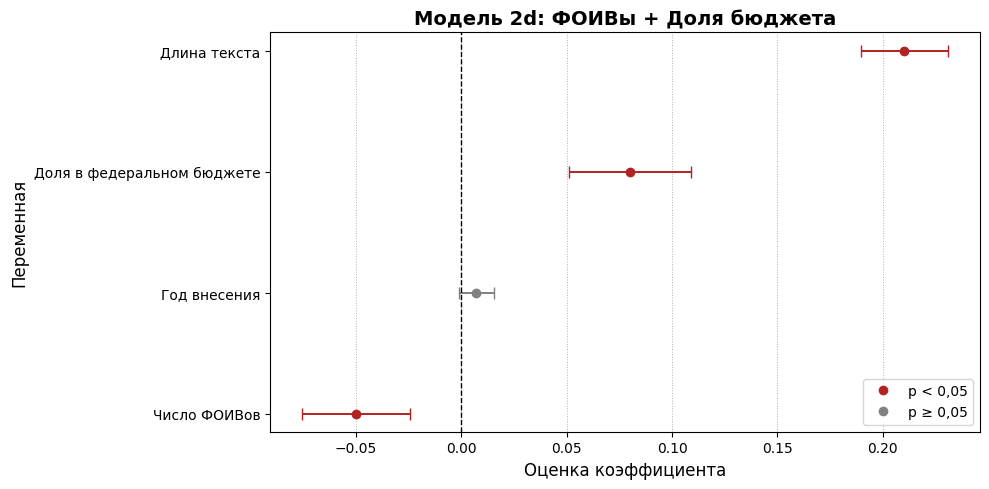

In [ ]:
plot_coefs(m2d, "Модель 2d: ФОИВы + Доля бюджета")

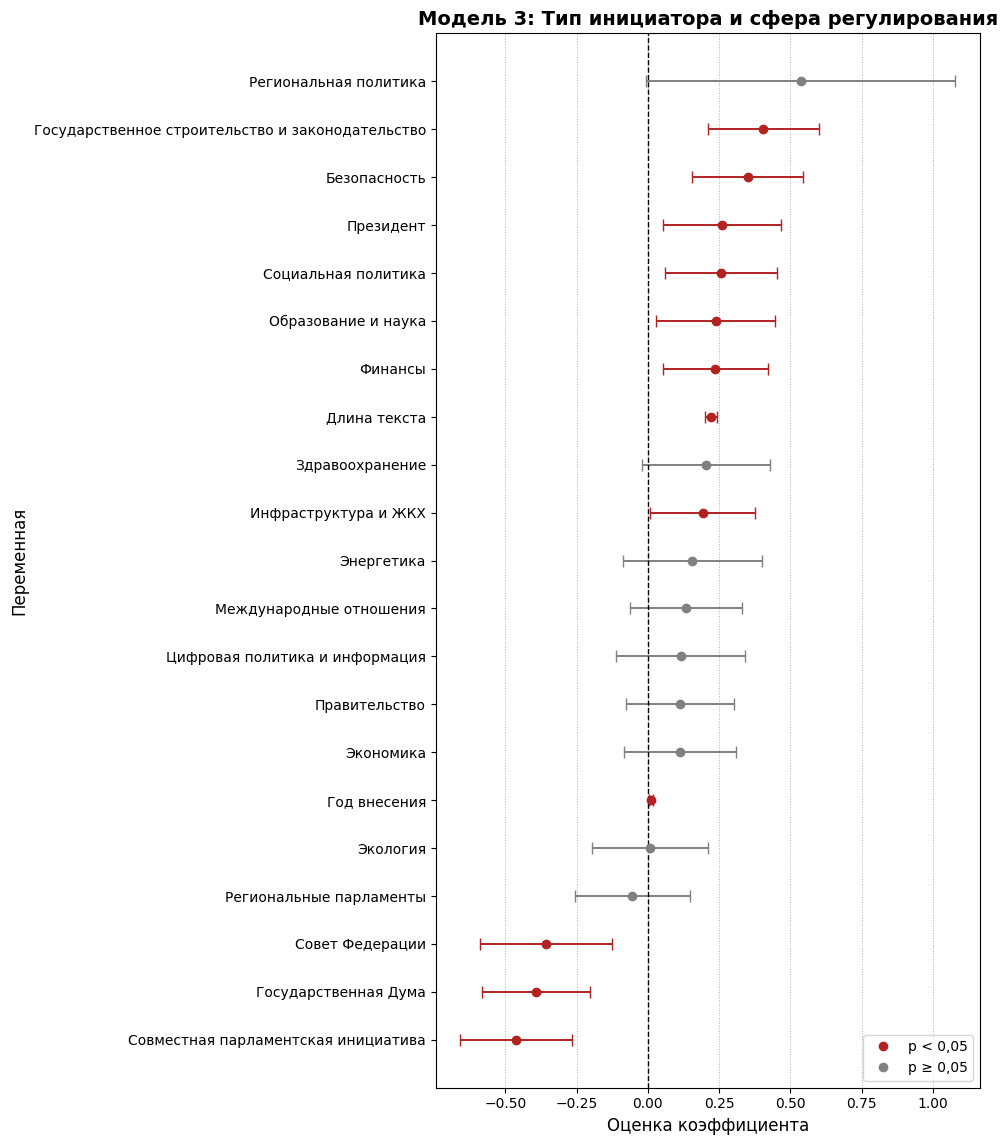

In [ ]:
plot_coefs(m3, "Модель 3: Тип инициатора и сфера регулирования")

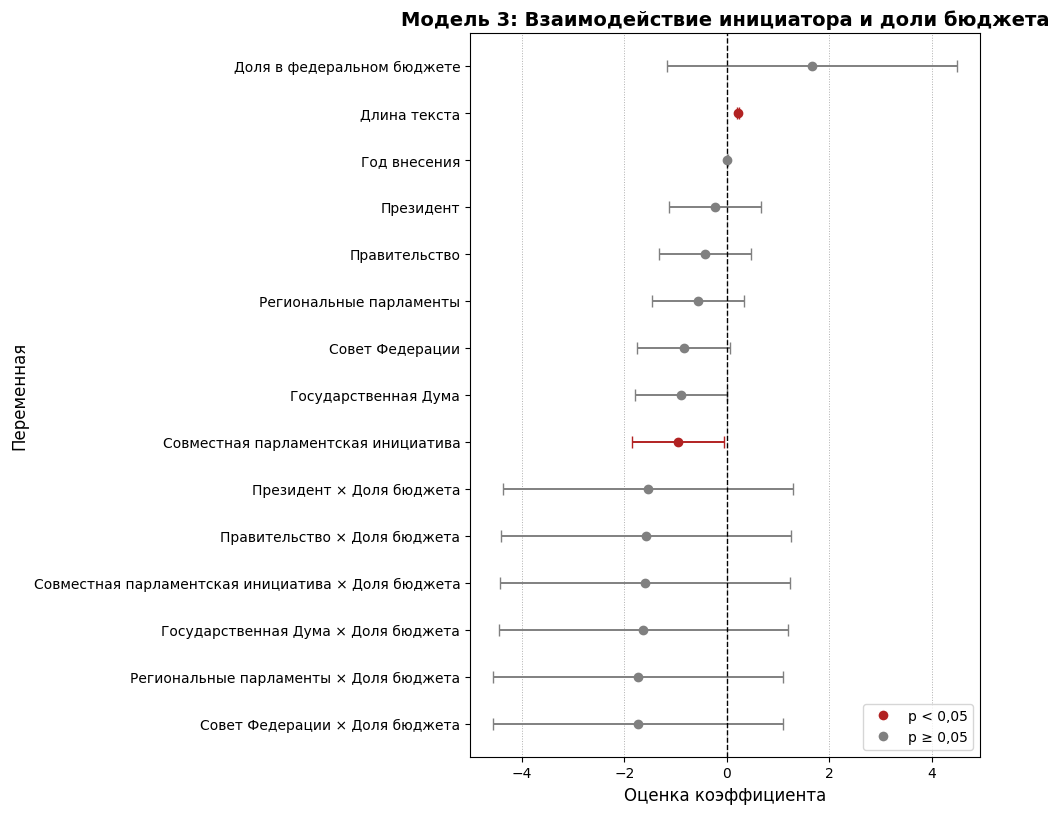

In [ ]:
plot_coefs(m3_interact, "Модель 3: Взаимодействие инициатора и доли бюджета")

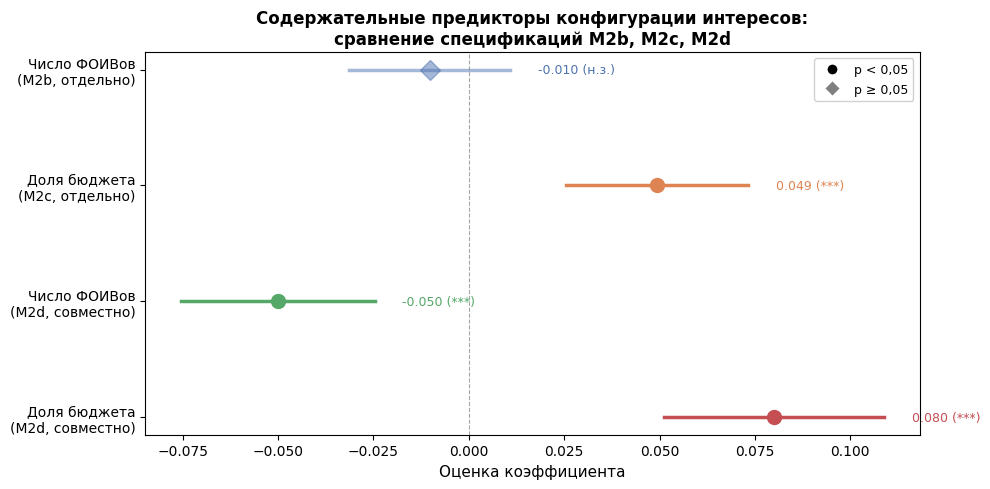

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

models_data = []

tbl_2b = get_coef_df(m2b)
row = tbl_2b.loc["n_foiv_std"]
models_data.append(("Число ФОИВов\n(M2b, отдельно)", row["coef"], row["ci_low"], row["ci_high"], row["pvalue"], "#4C72B0"))

tbl_2c = get_coef_df(m2c)
row = tbl_2c.loc["budget_share_std"]
models_data.append(("Доля бюджета\n(M2c, отдельно)", row["coef"], row["ci_low"], row["ci_high"], row["pvalue"], "#DD8452"))

tbl_2d = get_coef_df(m2d)
row = tbl_2d.loc["n_foiv_std"]
models_data.append(("Число ФОИВов\n(M2d, совместно)", row["coef"], row["ci_low"], row["ci_high"], row["pvalue"], "#55A868"))

row = tbl_2d.loc["budget_share_std"]
models_data.append(("Доля бюджета\n(M2d, совместно)", row["coef"], row["ci_low"], row["ci_high"], row["pvalue"], "#C44E52"))

y_positions = range(len(models_data))

for i, (label, coef, ci_lo, ci_hi, pval, color) in enumerate(models_data):
    marker = "o" if pval < 0.05 else "D"
    alpha = 1.0 if pval < 0.05 else 0.5
    ax.plot([ci_lo, ci_hi], [i, i], color=color, linewidth=2.5, alpha=alpha)
    ax.plot(coef, i, marker=marker, color=color, markersize=10, alpha=alpha, zorder=5)
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "н.з."
    ax.text(ci_hi + 0.005, i, f"  {coef:.3f} ({sig})", va="center", fontsize=9, color=color)

ax.axvline(x=0, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_yticks(list(y_positions))
ax.set_yticklabels([d[0] for d in models_data], fontsize=10)
ax.set_xlabel("Оценка коэффициента", fontsize=11)
ax.set_title("Содержательные предикторы конфигурации интересов:\nсравнение спецификаций M2b, M2c, M2d", fontsize=12, fontweight="bold")
ax.invert_yaxis()

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=8, label="p < 0,05"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="grey", markersize=8, label="p \u2265 0,05"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("coefs_comparison_m2.png", dpi=150, bbox_inches="tight")
plt.show()

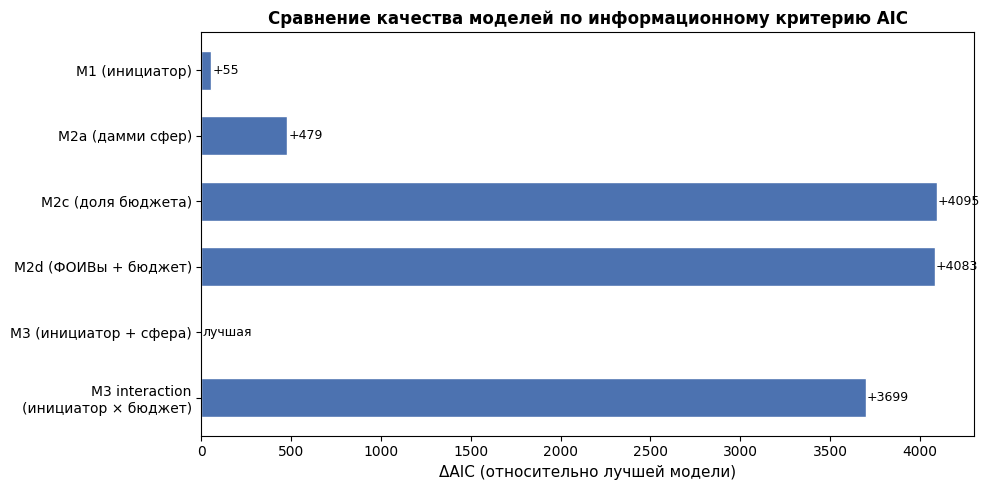

In [ ]:
model_names_aic = [
    "M1 (инициатор)",
    "M2a (дамми сфер)",
    "M2c (доля бюджета)",
    "M2d (ФОИВы + бюджет)",
    "M3 (инициатор + сфера)",
    "M3 interaction\n(инициатор \u00d7 бюджет)",
]

aic_values = [
    m1.aic,
    m2.aic,
    m2c.aic,
    m2d.aic,
    m3.aic,
    m3_interact.aic,
]

best_aic = min(aic_values)
delta_aic = [a - best_aic for a in aic_values]

fig, ax = plt.subplots(figsize=(10, 5))

colors_aic = ["#4C72B0"] * len(model_names_aic)
best_idx = delta_aic.index(0)
colors_aic[best_idx] = "#55A868"

bars = ax.barh(range(len(model_names_aic)), delta_aic, color=colors_aic, edgecolor="white", height=0.6)

ax.set_yticks(range(len(model_names_aic)))
ax.set_yticklabels(model_names_aic, fontsize=10)
ax.set_xlabel("\u0394AIC (относительно лучшей модели)", fontsize=11)
ax.set_title("Сравнение качества моделей по информационному критерию AIC", fontsize=12, fontweight="bold")
ax.invert_yaxis()

for i, (bar, delta) in enumerate(zip(bars, delta_aic)):
    label = "лучшая" if delta == 0 else f"+{delta:.0f}"
    ax.text(bar.get_width() + 5, i, label, va="center", fontsize=9)

plt.tight_layout()
plt.show()

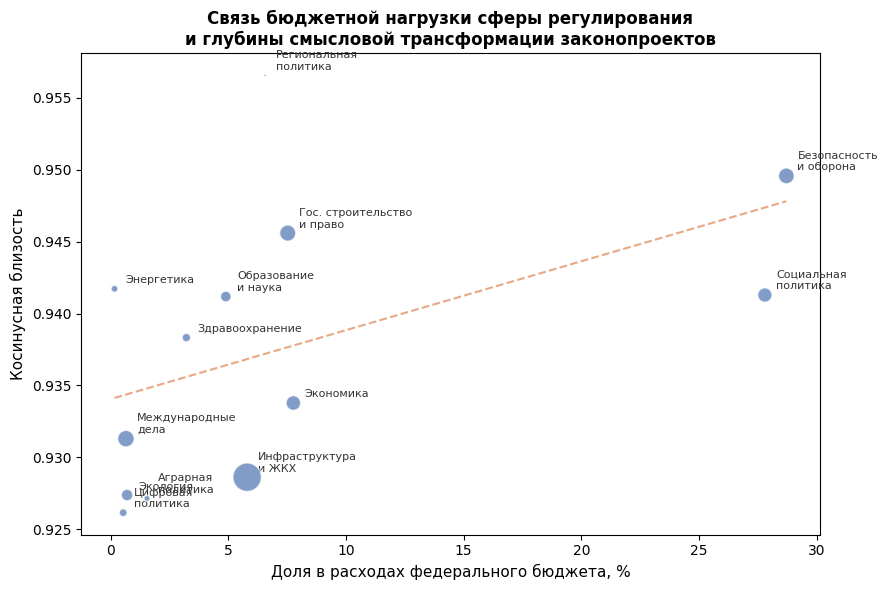

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

sphere_labels = {
    "AGRO": "Аграрная\nполитика",
    "DIGITAL_INFO": "Цифровая\nполитика",
    "ECOLOGY": "Экология",
    "ECONOMY": "Экономика",
    "EDUCATION": "Образование\nи наука",
    "ENERGY": "Энергетика",
    "FINANCE": "Финансы",
    "FOREIGN": "Международные\nдела",
    "HEALTH": "Здравоохранение",
    "INFRA": "Инфраструктура\nи ЖКХ",
    "LAW_STATE": "Гос. строительство\nи право",
    "REGIONAL": "Региональная\nполитика",
    "SECURITY": "Безопасность\nи оборона",
    "SOCIAL": "Социальная\nполитика",
}

sphere_stats = (
    df.dropna(subset=["budget_share", "depth"])
    .groupby("committee_group")
    .agg(
        mean_depth=("depth", "mean"),
        budget_pct=("budget_share", "first"),
        n=("depth", "count"),
    )
)

sphere_stats["budget_pct"] = sphere_stats["budget_pct"] * 100

ax.scatter(
    sphere_stats["budget_pct"],
    sphere_stats["mean_depth"],
    s=sphere_stats["n"] / 3,
    alpha=0.7,
    color="#4C72B0",
    edgecolors="white",
    linewidth=1,
    zorder=5,
)

for idx, row in sphere_stats.iterrows():
    label = sphere_labels.get(idx, idx)
    ax.annotate(
        label,
        (row["budget_pct"], row["mean_depth"]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8,
        color="#333333",
    )

z = np.polyfit(sphere_stats["budget_pct"], sphere_stats["mean_depth"], 1)
p = np.poly1d(z)
x_line = np.linspace(sphere_stats["budget_pct"].min(), sphere_stats["budget_pct"].max(), 100)
ax.plot(x_line, p(x_line), "--", color="#DD8452", linewidth=1.5, alpha=0.7)

ax.set_xlabel("Доля в расходах федерального бюджета, %", fontsize=11)
ax.set_ylabel("Косинусная близость", fontsize=11)
ax.set_title(
    "Связь бюджетной нагрузки сферы регулирования\nи глубины смысловой трансформации законопроектов",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig("budget_vs_depth.png", dpi=150, bbox_inches="tight")
plt.show()